# **Estatistica S4**

### ***Exames citopatológicos realizados em mulheres na faixa etária de 25 a 64 anos***


> Quantidade de exames citopatológicos (Papanicolau, Exame citopatológico cérvico-vaginal/microflora e Exame citopatológico cérvico-vaginal microflora-rastreamento) realizados em mulheres na faixa etária de 25 a 64 anos por município/UF de residência.

### ***Hospitais habilitados para o tratamento do câncer em alta complexidade***

> Quantidade de hospitais habilitados para tratamento do câncer em alta complexidade conforme definição de critérios e parâmetros referenciais para a habilitação de estabelecimentos de saúde na alta complexidade em oncologia no SUS

### **Compreensão dos dados**

### _Objetivo e Finalidade_

Essa análise possui o objetivo de realizar uma exploração dos dados do Dataset, Identificar dispridades e analisar a saúde publica até a ultima atualzação da base de dados do governo:

- Dados atualizados pela última vez em 24 de novembro de 2025, 21:00 (UTC-03:00)
- Metadados atualizados pela última vez	em 25 de novembro de 2025, 12:27 (UTC-03:00)

Afim de entender as distribuições geograficas de exames (Quais estados/regioes fazem mais testes?), anaisar as tendencias temporais (teve aumento ou diminuição com o passar dos tempos?), indicar padrões regionais, comparar as estatisticas entre municipios, estados e regiões, encontrar áreas de baixa cobertura, detectar anomalias, avaliar efetividade dos programas de rastreamento por região e identificar a prioridade de intervenção...

#### _Importando as dependencias_

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import statistics as sta
import os

#### _Visualizando todas as colunas e as 10 primeiras linhas para entender como os dados se comportam_

In [6]:
silver_df = pd.read_csv('../../Datasets/ccmec25a64_main.csv')
print(silver_df.columns.tolist())
silver_df.head(10)

['co_anomes', 'co_ibge', 'vl_indicador_calculado_mun', 'co_uf', 'no_municipio', 'sg_uf', 'no_uf', 'co_regiao_brasil', 'no_regiao_brasil', 'sg_regiao_brasil', 'co_regiao_saude', 'no_regiao_saude', 'no_macro', 'co_macro', 'vl_indicador_calculado_rs', 'vl_indicador_calculado_ms', 'vl_indicador_calculado_uf', 'vl_indicador_calculado_reg', 'vl_indicador_calculado_br', 'vl_indicador_calculado_al', 'dt_competencia', 'dt_atualizacao', 'ds_unidade_medida', 'sg_granularidade', 'ds_granularidade']


,co_anomes,co_ibge,vl_indicador_calculado_mun,co_uf,no_municipio,sg_uf,no_uf,co_regiao_brasil,no_regiao_brasil,sg_regiao_brasil,...,vl_indicador_calculado_ms,vl_indicador_calculado_uf,vl_indicador_calculado_reg,vl_indicador_calculado_br,vl_indicador_calculado_al,dt_competencia,dt_atualizacao,ds_unidade_medida,sg_granularidade,ds_granularidade
0,202512,412440,0.0,41,Santo Antônio do Sudoeste,PR,Paraná,4,Sul,S,...,126079.0,506911.0,1265634.0,7292814.0,0.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Número,MN,Município
1,202512,412450,0.0,41,Santo Inácio,PR,Paraná,4,Sul,S,...,75051.0,506911.0,1265634.0,7292814.0,0.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Número,MN,Município
2,202512,412460,0.0,41,São Carlos do Ivaí,PR,Paraná,4,Sul,S,...,75051.0,506911.0,1265634.0,7292814.0,0.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Número,MN,Município
3,202512,412470,0.0,41,São Jerônimo da Serra,PR,Paraná,4,Sul,S,...,65572.0,506911.0,1265634.0,7292814.0,0.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Número,MN,Município
4,202512,412480,0.0,41,São João,PR,Paraná,4,Sul,S,...,126079.0,506911.0,1265634.0,7292814.0,0.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Número,MN,Município
5,202512,412490,0.0,41,São João do Caiuá,PR,Paraná,4,Sul,S,...,75051.0,506911.0,1265634.0,7292814.0,0.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Número,MN,Município
6,202512,412500,0.0,41,São João do Ivaí,PR,Paraná,4,Sul,S,...,65572.0,506911.0,1265634.0,7292814.0,0.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Número,MN,Município
7,202512,412510,0.0,41,São João do Triunfo,PR,Paraná,4,Sul,S,...,240209.0,506911.0,1265634.0,7292814.0,0.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Número,MN,Município
8,202512,412520,0.0,41,São Jorge D'Oeste,PR,Paraná,4,Sul,S,...,126079.0,506911.0,1265634.0,7292814.0,0.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Número,MN,Município
9,202512,412530,0.0,41,São Jorge do Ivaí,PR,Paraná,4,Sul,S,...,75051.0,506911.0,1265634.0,7292814.0,0.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Número,MN,Município


#### _Descrição detalhada de cada coluna_

In [7]:
# Gerando documentação das colunas
print("# DOCUMENTAÇÃO DO DATASET - EXAMES CITOPATOLÓGICOS\n")
print("## Visão Geral")
print(f"- **Total de registros**: {len(silver_df):,}")
print(f"- **Total de colunas**: {len(silver_df.columns)}")
print(f"- **Última atualização**: 24 de novembro de 2025\n")

print("## Descrição Detalhada das Colunas\n")

for i, column in enumerate(silver_df.columns, 1):
    print(f"### {i}. {column}")
    print(f"**Tipo de dado**: {silver_df[column].dtype}")
    print(f"**Valores únicos**: {silver_df[column].nunique():,}")
    print(f"**Valores nulos**: {silver_df[column].isnull().sum():,} ({silver_df[column].isnull().sum()/len(silver_df)*100:.1f}%)")

    # Para colunas numéricas
    if silver_df[column].dtype in ['int64', 'float64']:
        print("**Estatísticas**:")
        print(f"  - Média: {silver_df[column].mean():,.2f}")
        print(f"  - Mediana: {silver_df[column].median():,.2f}")
        print(f"  - Mínimo: {silver_df[column].min():,}")
        print(f"  - Máximo: {silver_df[column].max():,}")
        print(f"  - Desvio padrão: {silver_df[column].std():,.2f}")
    else:
        # Para colunas de texto
        unique_values = silver_df[column].dropna().unique()
        if len(unique_values) <= 10:
            print(f"**Valores únicos**: {', '.join(str(v) for v in unique_values)}")
        else:
            print(f"**Primeiros valores únicos**: {', '.join(str(v) for v in unique_values[:10])}...")

    print()

print("---")
print("*Documentação gerada automaticamente em", pd.Timestamp.now().strftime("%d/%m/%Y %H:%M"))

# DOCUMENTAÇÃO DO DATASET - EXAMES CITOPATOLÓGICOS

## Visão Geral
- **Total de registros**: 55,702
- **Total de colunas**: 25
- **Última atualização**: 24 de novembro de 2025

## Descrição Detalhada das Colunas

### 1. co_anomes
**Tipo de dado**: int64
**Valores únicos**: 10
**Valores nulos**: 0 (0.0%)
**Estatísticas**:
  - Média: 202,062.01
  - Mediana: 202,112.00
  - Mínimo: 201,612
  - Máximo: 202,512
  - Desvio padrão: 287.24

### 2. co_ibge
**Tipo de dado**: int64
**Valores únicos**: 5,571
**Valores nulos**: 0 (0.0%)
**Estatísticas**:
  - Média: 325,365.26
  - Mediana: 314,630.00
  - Mínimo: 110,001
  - Máximo: 530,010
  - Desvio padrão: 98,487.54

### 3. vl_indicador_calculado_mun
**Tipo de dado**: float64
**Valores únicos**: 4,742
**Valores nulos**: 0 (0.0%)
**Estatísticas**:
  - Média: 1,216.20
  - Mediana: 0.00
  - Mínimo: 0.0
  - Máximo: 710,451.0
  - Desvio padrão: 11,592.49

### 4. co_uf
**Tipo de dado**: int64
**Valores únicos**: 27
**Valores nulos**: 0 (0.0%)
**Estatísti

#### _Classificação das variáveis por escala de medida_

In [8]:
def infer_scale(column_series):
    # Inferência robusta do dtype e escala de medida
    if pd.api.types.is_datetime64_any_dtype(column_series):
        return 'Temporal (intervalar/razão)'

    # data em string no formato ISO ou dd/mm/yyyy podem ser convertedas
    if column_series.dtype == 'string' or column_series.dtype == object:
        try:
            converted = pd.to_datetime(column_series, errors='coerce')
            if converted.notna().sum() / len(column_series) > 0.9:
                return 'Temporal (intervalar/razão) - string'
        except Exception:
            pass
        return 'Nominal'  # strings são normalmente nominais

    if pd.api.types.is_categorical_dtype(column_series):
        # se categoria ordenada definida no pandas
        if getattr(column_series.dtype, 'ordered', False):
            return 'Ordinal'
        return 'Nominal'

    if pd.api.types.is_integer_dtype(column_series):
        unique = column_series.nunique(dropna=True)
        if unique < 30:
            return 'Discreta (categoria numérica/ordinal)'
        return 'Discreta'

    if pd.api.types.is_float_dtype(column_series):
        return 'Contínua'

    return 'Desconhecida'

scale_info = []
for col in silver_df.columns:
    dtype = silver_df[col].dtype
    scale = infer_scale(silver_df[col])
    scale_info.append({'coluna': col, 'tipo': str(dtype), 'escala': scale, 'valores_unicos': silver_df[col].nunique(dropna=True)})

scale_df = pd.DataFrame(scale_info)
scale_df


C:\Users\tecla\AppData\Local\Temp\ipykernel_12096\1917965802.py:16: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(column_series):
C:\Users\tecla\AppData\Local\Temp\ipykernel_12096\1917965802.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted = pd.to_datetime(column_series, errors='coerce')
C:\Users\tecla\AppData\Local\Temp\ipykernel_12096\1917965802.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted = pd.to_datetime(column_series, errors='coerce')
C:\Users\tecla\AppData\Local\Temp\ipykernel_12096\1917965802.py:9: UserWarning: Could not infer format, so eac

,coluna,tipo,escala,valores_unicos
0,co_anomes,int64,Discreta (categoria numérica/ordinal),10
1,co_ibge,int64,Discreta,5571
2,vl_indicador_calculado_mun,float64,Contínua,4742
3,co_uf,int64,Discreta (categoria numérica/ordinal),27
4,no_municipio,str,Nominal,5299
5,sg_uf,str,Nominal,27
6,no_uf,str,Nominal,27
7,co_regiao_brasil,int64,Discreta (categoria numérica/ordinal),5
8,no_regiao_brasil,str,Nominal,5
9,sg_regiao_brasil,str,Nominal,5


#### _Análise de Limitações, Vieses e Lacunas dos Dados_

> Contém parte Outliers e desvios de padrões

In [9]:
print("=" * 80)
print("ANÁLISE DE LIMITAÇÕES, VIESES E LACUNAS DOS DADOS SECUNDÁRIOS")
print("=" * 80)
print()

# 1. COMPLETUDE DOS DADOS
print("1️⃣  COMPLETUDE E VALORES FALTANTES")
print("-" * 80)
missing_summary = pd.DataFrame({
    'Coluna': silver_df.columns,
    'Valores Nulos': [silver_df[col].isnull().sum() for col in silver_df.columns],
    'Percentual (%)': [f"{silver_df[col].isnull().sum()/len(silver_df)*100:.2f}%" for col in silver_df.columns],
    'Taxa Completude': [f"{(1 - silver_df[col].isnull().sum()/len(silver_df))*100:.2f}%" for col in silver_df.columns]
})
print(missing_summary.to_string(index=False))
print()

# 2. COBERTURA TEMPORAL
print("\n2️⃣  COBERTURA TEMPORAL")
print("-" * 80)
try:
    datas = pd.to_datetime(silver_df['dt_competencia'], errors='coerce')
    print(f"Data mais antiga: {datas.min()}")
    print(f"Data mais recente: {datas.max()}")
    print(f"Períodos únicos: {datas.dt.to_period('M').nunique()}")
    print(f"Intervalo temporal: {(datas.max() - datas.min()).days} dias")
    print("✓ Lacuna potencial: Dados podem não cobrir todos os períodos continuamente")
except Exception as e:
    print(f"Erro ao processar datas: {e}")
print()

# 3. COBERTURA GEOGRÁFICA
print("\n3️⃣  COBERTURA GEOGRÁFICA")
print("-" * 80)
print(f"Estados (UF) cobertos: {silver_df['sg_uf'].nunique()} (máx 27 = 26 + DF)")
print(f"Municípios cobertos: {silver_df['no_municipio'].nunique()}")
print(f"Regiões de Saúde: {silver_df['no_regiao_saude'].nunique()}")
print(f"Macrorregiões: {silver_df['no_macro'].nunique()}")

# Verificar se todos os UFs estão representados
ufs_esperadas = 27  # 26 estados + DF
ufs_presentes = silver_df['sg_uf'].nunique()
if ufs_presentes < ufs_esperadas:
    print(f"⚠️  ALERTA: Apenas {ufs_presentes}/{ufs_esperadas} UFs representadas")
    ufs_ausentes = set(silver_df['sg_uf'].dropna().unique())
    print(f"   Investigar quais UFs faltam no dataset")
else:
    print(f"✓ Todas as {ufs_esperadas} UFs estão representadas")
print()

# 4. DISTRIBUIÇÃO DE VALORES NOS INDICADORES
print("\n4️⃣  DISTRIBUIÇÃO E VALORES EXTREMOS (INDICADORES)")
print("-" * 80)
indicator_cols = [col for col in silver_df.columns if 'vl_indicador' in col]
for col in indicator_cols:
    vals = silver_df[col].dropna()
    print(f"\n{col}:")
    print(f"  • Mínimo: {vals.min():.2f}")
    print(f"  • Máximo: {vals.max():.2f}")
    print(f"  • Média: {vals.mean():.2f}")
    print(f"  • Mediana: {vals.median():.2f}")
    print(f"  • Desvio Padrão: {vals.std():.2f}")
    
    # Detecção de outliers usando IQR
    Q1 = vals.quantile(0.25)
    Q3 = vals.quantile(0.75)
    IQR = Q3 - Q1
    outliers = vals[(vals < Q1 - 1.5*IQR) | (vals > Q3 + 1.5*IQR)]
    print(f"  • Outliers (IQR): {len(outliers)} valores ({len(outliers)/len(vals)*100:.2f}%)")
print()


ANÁLISE DE LIMITAÇÕES, VIESES E LACUNAS DOS DADOS SECUNDÁRIOS

1️⃣  COMPLETUDE E VALORES FALTANTES
--------------------------------------------------------------------------------
                    Coluna  Valores Nulos Percentual (%) Taxa Completude
                 co_anomes              0          0.00%         100.00%
                   co_ibge              0          0.00%         100.00%
vl_indicador_calculado_mun              0          0.00%         100.00%
                     co_uf              0          0.00%         100.00%
              no_municipio              0          0.00%         100.00%
                     sg_uf              0          0.00%         100.00%
                     no_uf              0          0.00%         100.00%
          co_regiao_brasil              0          0.00%         100.00%
          no_regiao_brasil              0          0.00%         100.00%
          sg_regiao_brasil              0          0.00%         100.00%
           co_reg

5️⃣  VIESES ESTRUTURAIS E LACUNAS IDENTIFICADAS

📊 VIESES POTENCIAIS:
  1. Viés Geográfico: Cobertura desigual entre municípios (dados por município vs estado)
  2. Viés Temporal: Dados podem ter atraso de notificação/processamento
  3. Viés de Seleção: Sistema depende de acesso à rede de saúde (pública/privada)
  4. Viés de Subnotificação: Nem todas as mulheres têm acesso igual a exames
  5. Viés Socioeconômico: Regiões mais desenvolvidas podem ter maior cobertura

❌ LACUNAS IDENTIFICADAS:
  1. Dados faltantes em colunas de indicadores (valores NaN)
  2. Falta de informações sobre:
     - Características demográficas das mulheres (escolaridade, renda, etc.)
     - Resultados dos exames (positivo/negativo/inconclusivo)
     - Desfechos clínicos (diagnóstico de câncer, tratamento)
  3. Ausência de:
     - Dados sobre fatores de risco (tabagismo, número de parceiros, etc.)
     - Informações sobre cobertura de vacinação (HPV)
     - Comparativo com população-alvo (mulheres 25-64 anos)

⚠️  RESTRIÇÕES E LIMITAÇÕES:
  1. Dados secundários: Dependem da qualidade de registro das instituições
  2. Agregação: Dados agregados podem mascarar variações locais importantes
  3. Periodicidade: Frequência de atualização pode comprometer análises recentes
  4. Cobertura incompleta: Pode não incluir setor privado completamente
  5. Comparabilidade: Mudanças em metodologia de coleta ao longo do tempo

### **Limpeza e Preparação**

#### _Verificando se a alguma coluna possui dados nulos e mostra as 10 primerias linhas para visualizar os dados_

In [11]:
bronze_df = silver_df.drop(['co_anomes', 'co_ibge', 'co_uf', 'co_regiao_brasil', 'co_regiao_saude'], axis=1)

for column in bronze_df.columns:
  print(f"{column}: {bronze_df[column].isnull().unique()}")

bronze_df.head(10)

vl_indicador_calculado_mun: [False]
no_municipio: [False]
sg_uf: [False]
no_uf: [False]
no_regiao_brasil: [False]
sg_regiao_brasil: [False]
no_regiao_saude: [False]
no_macro: [False]
co_macro: [False]
vl_indicador_calculado_rs: [False]
vl_indicador_calculado_ms: [False]
vl_indicador_calculado_uf: [False]
vl_indicador_calculado_reg: [False]
vl_indicador_calculado_br: [False]
vl_indicador_calculado_al: [False]
dt_competencia: [False]
dt_atualizacao: [False]
ds_unidade_medida: [False]
sg_granularidade: [False]
ds_granularidade: [False]


,vl_indicador_calculado_mun,no_municipio,sg_uf,no_uf,no_regiao_brasil,sg_regiao_brasil,no_regiao_saude,no_macro,co_macro,vl_indicador_calculado_rs,vl_indicador_calculado_ms,vl_indicador_calculado_uf,vl_indicador_calculado_reg,vl_indicador_calculado_br,vl_indicador_calculado_al,dt_competencia,dt_atualizacao,ds_unidade_medida,sg_granularidade,ds_granularidade
0,0.0,Santo Antônio do Sudoeste,PR,Paraná,Sul,S,8ª RS Francisco Beltrão,Macrorregião Oeste,4108,55878.0,126079.0,506911.0,1265634.0,7292814.0,0.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Número,MN,Município
1,0.0,Santo Inácio,PR,Paraná,Sul,S,15ª RS Maringá,Macrorregional Noroeste,4106,35864.0,75051.0,506911.0,1265634.0,7292814.0,0.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Número,MN,Município
2,0.0,São Carlos do Ivaí,PR,Paraná,Sul,S,14ª RS Paranavaí,Macrorregional Noroeste,4106,12689.0,75051.0,506911.0,1265634.0,7292814.0,0.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Número,MN,Município
3,0.0,São Jerônimo da Serra,PR,Paraná,Sul,S,18ª RS Cornélio Procópio,Macrorregional Norte,4105,0.0,65572.0,506911.0,1265634.0,7292814.0,0.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Número,MN,Município
4,0.0,São João,PR,Paraná,Sul,S,7ª RS Pato Branco,Macrorregião Oeste,4108,9052.0,126079.0,506911.0,1265634.0,7292814.0,0.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Número,MN,Município
5,0.0,São João do Caiuá,PR,Paraná,Sul,S,14ª RS Paranavaí,Macrorregional Noroeste,4106,12689.0,75051.0,506911.0,1265634.0,7292814.0,0.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Número,MN,Município
6,0.0,São João do Ivaí,PR,Paraná,Sul,S,22ª RS IV aiporã,Macrorregional Norte,4105,0.0,65572.0,506911.0,1265634.0,7292814.0,0.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Número,MN,Município
7,0.0,São João do Triunfo,PR,Paraná,Sul,S,3ª RS Ponta Grossa,Macrorregional Leste,4107,0.0,240209.0,506911.0,1265634.0,7292814.0,0.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Número,MN,Município
8,0.0,São Jorge D'Oeste,PR,Paraná,Sul,S,8ª RS Francisco Beltrão,Macrorregião Oeste,4108,55878.0,126079.0,506911.0,1265634.0,7292814.0,0.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Número,MN,Município
9,0.0,São Jorge do Ivaí,PR,Paraná,Sul,S,15ª RS Maringá,Macrorregional Noroeste,4106,35864.0,75051.0,506911.0,1265634.0,7292814.0,0.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Número,MN,Município


#### _Criando tabela Gold - Remossão de colunas_

In [13]:
# Criando tabela Gold - Dados finais filtrados e limpos
gold_df = bronze_df.drop(['vl_indicador_calculado_mun', 'sg_regiao_brasil', 'co_macro',
                          'vl_indicador_calculado_al', 'ds_unidade_medida', 'sg_granularidade'], axis=1)

print("=" * 60)
print("TABELA GOLD - DADOS FINAIS FILTRADOS")
print("=" * 60)
print(f"Total de registros: {len(gold_df):,}")
print(f"Total de colunas: {len(gold_df.columns)}")
# print(f"Colunas restantes: {list(gold_df.columns)}")
print()

print("VERIFICAÇÃO DE VALORES NULOS:")
print("-" * 40)
for column in gold_df.columns:
    n_null = gold_df[column].isnull().sum()
    pct_null = 100 * n_null / len(gold_df)
    print(f"{column}: {n_null} nulos ({pct_null:.2f}%)")

print()
print("PRIMEIRAS 10 LINHAS DA TABELA GOLD:")
print("-" * 40)
gold_df.head(10)

TABELA GOLD - DADOS FINAIS FILTRADOS
Total de registros: 55,702
Total de colunas: 14

VERIFICAÇÃO DE VALORES NULOS:
----------------------------------------
no_municipio: 0 nulos (0.00%)
sg_uf: 0 nulos (0.00%)
no_uf: 0 nulos (0.00%)
no_regiao_brasil: 0 nulos (0.00%)
no_regiao_saude: 0 nulos (0.00%)
no_macro: 0 nulos (0.00%)
vl_indicador_calculado_rs: 0 nulos (0.00%)
vl_indicador_calculado_ms: 0 nulos (0.00%)
vl_indicador_calculado_uf: 0 nulos (0.00%)
vl_indicador_calculado_reg: 0 nulos (0.00%)
vl_indicador_calculado_br: 0 nulos (0.00%)
dt_competencia: 0 nulos (0.00%)
dt_atualizacao: 0 nulos (0.00%)
ds_granularidade: 0 nulos (0.00%)

PRIMEIRAS 10 LINHAS DA TABELA GOLD:
----------------------------------------


,no_municipio,sg_uf,no_uf,no_regiao_brasil,no_regiao_saude,no_macro,vl_indicador_calculado_rs,vl_indicador_calculado_ms,vl_indicador_calculado_uf,vl_indicador_calculado_reg,vl_indicador_calculado_br,dt_competencia,dt_atualizacao,ds_granularidade
0,Santo Antônio do Sudoeste,PR,Paraná,Sul,8ª RS Francisco Beltrão,Macrorregião Oeste,55878.0,126079.0,506911.0,1265634.0,7292814.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Município
1,Santo Inácio,PR,Paraná,Sul,15ª RS Maringá,Macrorregional Noroeste,35864.0,75051.0,506911.0,1265634.0,7292814.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Município
2,São Carlos do Ivaí,PR,Paraná,Sul,14ª RS Paranavaí,Macrorregional Noroeste,12689.0,75051.0,506911.0,1265634.0,7292814.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Município
3,São Jerônimo da Serra,PR,Paraná,Sul,18ª RS Cornélio Procópio,Macrorregional Norte,0.0,65572.0,506911.0,1265634.0,7292814.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Município
4,São João,PR,Paraná,Sul,7ª RS Pato Branco,Macrorregião Oeste,9052.0,126079.0,506911.0,1265634.0,7292814.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Município
5,São João do Caiuá,PR,Paraná,Sul,14ª RS Paranavaí,Macrorregional Noroeste,12689.0,75051.0,506911.0,1265634.0,7292814.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Município
6,São João do Ivaí,PR,Paraná,Sul,22ª RS IV aiporã,Macrorregional Norte,0.0,65572.0,506911.0,1265634.0,7292814.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Município
7,São João do Triunfo,PR,Paraná,Sul,3ª RS Ponta Grossa,Macrorregional Leste,0.0,240209.0,506911.0,1265634.0,7292814.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Município
8,São Jorge D'Oeste,PR,Paraná,Sul,8ª RS Francisco Beltrão,Macrorregião Oeste,55878.0,126079.0,506911.0,1265634.0,7292814.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Município
9,São Jorge do Ivaí,PR,Paraná,Sul,15ª RS Maringá,Macrorregional Noroeste,35864.0,75051.0,506911.0,1265634.0,7292814.0,2025-12-01 12:00:00,2026-03-17 01:09:47,Município


#### _Contagem de linhas das tabelas_

In [15]:
# Contagem de linhas das tabelas
print("=" * 50)
print("CONTAGEM DE LINHAS DAS TABELAS")
print("=" * 50)

# Bronze (dados brutos)
bronze_rows = len(bronze_df)
bronze_cols = len(bronze_df.columns)

# Silver (dados filtrados - primeiras remoções)
silver_rows = len(silver_df)
silver_cols = len(silver_df.columns)

# Gold (dados finais - remoções adicionais)
gold_rows = len(gold_df)
gold_cols = len(gold_df.columns)

print(f"BRONZE (dados brutos): {bronze_rows:,} linhas × {bronze_cols} colunas")
print(f"SILVER (filtrado inicial): {silver_rows:,} linhas × {silver_cols} colunas")
print(f"GOLD (filtrado final): {gold_rows:,} linhas × {gold_cols} colunas")
print()

# Comparação
print("COMPARAÇÃO:")
print(f"Linhas removidas (Bronze → Silver): {bronze_rows - silver_rows:,}")
print(f"Linhas removidas (Silver → Gold): {silver_rows - gold_rows:,}")
print(f"Linhas removidas (Bronze → Gold): {bronze_rows - gold_rows:,}")
print()


CONTAGEM DE LINHAS DAS TABELAS
BRONZE (dados brutos): 55,702 linhas × 20 colunas
SILVER (filtrado inicial): 55,702 linhas × 25 colunas
GOLD (filtrado final): 55,702 linhas × 14 colunas

COMPARAÇÃO:
Linhas removidas (Bronze → Silver): 0
Linhas removidas (Silver → Gold): 0
Linhas removidas (Bronze → Gold): 0



#### _Analise cruzada com tabela de "Hospitais habilitados para o tratamento do câncer em alta complexidade"_

In [17]:
bronze_df = pd.read_csv('../../Datasets/ccmhhcac.csv')

# Filtrando apenas as colunas essenciais
colunas_essenciais = ['no_municipio', 'sg_uf', 'no_uf', 'no_regiao_brasil', 'vl_indicador_calculado_ms']
bronze_df = bronze_df[colunas_essenciais]

# print("Colunas mantidas:", bronze_df.columns.tolist())
print(f"Total de registros: {len(bronze_df):,}")
print(f"Total de colunas: {len(bronze_df.columns)}")
print()

print("Primeiras 10 linhas:")
bronze_df.head(10)

Total de registros: 55,702
Total de colunas: 5

Primeiras 10 linhas:


,no_municipio,sg_uf,no_uf,no_regiao_brasil,vl_indicador_calculado_ms
0,Santo Antônio do Sudoeste,PR,Paraná,Sul,5
1,Santo Inácio,PR,Paraná,Sul,4
2,São Carlos do Ivaí,PR,Paraná,Sul,4
3,São Jerônimo da Serra,PR,Paraná,Sul,4
4,São João,PR,Paraná,Sul,5
5,São João do Caiuá,PR,Paraná,Sul,4
6,São João do Ivaí,PR,Paraná,Sul,4
7,São João do Triunfo,PR,Paraná,Sul,11
8,São Jorge D'Oeste,PR,Paraná,Sul,5
9,São Jorge do Ivaí,PR,Paraná,Sul,4


#### _Análise Cruzada: Exames Citopatológicos vs Hospitais Habilitados_

ANÁLISE CRUZADA: EXAMES CITOPATOLÓGICOS vs HOSPITAIS HABILITADOS
CARREGANDO DATASETS
--------------------------------------------------
Exames Citopatológicos: 55,702 registros
Hospitais Habilitados: 55,702 registros

ANÁLISE POR MACRORREGIÃO
--------------------------------------------------
Tabela Cruzada - Exames vs Hospitais por Região:
                  exames_media  exames_total  exames_contagem  hospitais_media  hospitais_total  hospitais_contagem
no_regiao_brasil                                                                                                   
Centro-Oeste              0.98          4566             4672           832.20        3888037.0                4672
Nordeste                  2.07         37192            17940           917.89       16467024.0               17940
Norte                     0.87          3907             4500           987.13        4442070.0                4500
Sudeste                   4.78         79812            16680          1850.2

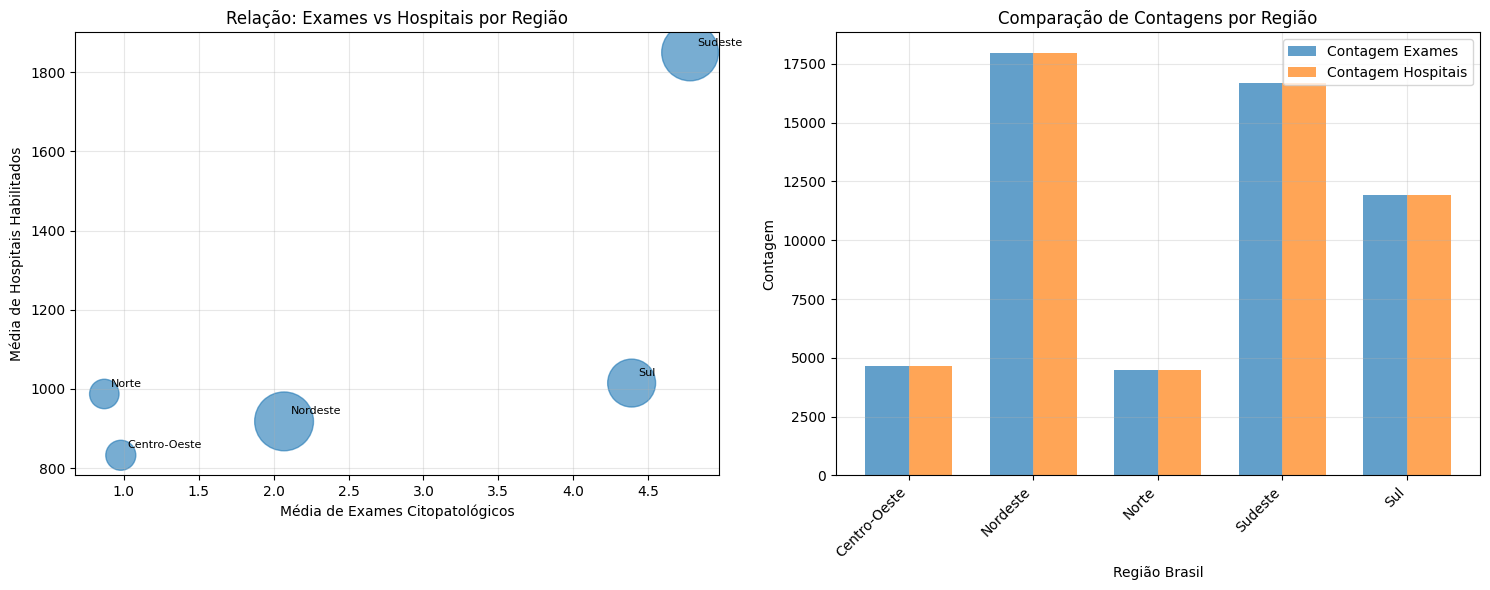


CONCLUSÃO DA ANÁLISE CRUZADA
Esta análise compara a distribuição de exames citopatológicos
com a disponibilidade de hospitais habilitados para tratamento
de câncer em alta complexidade, por região brasileira.


In [21]:
# ANÁLISE CRUZADA: Exames Citopatológicos vs Hospitais Habilitados

print("=" * 80)
print("ANÁLISE CRUZADA: EXAMES CITOPATOLÓGICOS vs HOSPITAIS HABILITADOS")
print("=" * 80)

# 1. CARREGAR OS DOIS DATASETS
print("CARREGANDO DATASETS")
print("-" * 50)

# Dataset 1: Exames Citopatológicos (ccmhhcac.csv)
exames_df = pd.read_csv('../../Datasets/ccmhhcac.csv')
colunas_exames = ['no_municipio', 'sg_uf', 'no_uf', 'no_regiao_brasil', 'vl_indicador_calculado_ms']
exames_df = exames_df[colunas_exames].copy()

# Dataset 2: Hospitais Habilitados (ccmec25a64.csv)
hospitais_df = pd.read_csv('../../Datasets/ccmec25a64_main.csv')
print(f"Exames Citopatológicos: {len(exames_df):,} registros")
print(f"Hospitais Habilitados: {len(hospitais_df):,} registros")
# print(f"Colunas Exames: {list(exames_df.columns)}")
# print(f"Colunas Hospitais: {list(hospitais_df.columns)}")
print()

# 2. ANÁLISE POR MACRORREGIÃO
print("ANÁLISE POR MACRORREGIÃO")
print("-" * 50)

# Verificar se existe coluna de macrorregião nos hospitais
if 'no_macro' in hospitais_df.columns:
    # Agregação por macrorregião
    exames_macro = exames_df.groupby('no_regiao_brasil')['vl_indicador_calculado_ms'].agg(['mean', 'sum', 'count']).round(2)
    exames_macro.columns = ['exames_media', 'exames_total', 'exames_contagem']

    # Para hospitais, vamos contar por macrorregião (assumindo que há uma coluna de contagem)
    hospitais_cols = [col for col in hospitais_df.columns if 'vl_indicador' in col or 'qtde' in col.lower() or 'quantidade' in col.lower()]
    if hospitais_cols:
        hosp_col = hospitais_cols[0]  # pega a primeira coluna de indicador
        hospitais_macro = hospitais_df.groupby('no_regiao_brasil')[hosp_col].agg(['mean', 'sum', 'count']).round(2)
        hospitais_macro.columns = ['hospitais_media', 'hospitais_total', 'hospitais_contagem']
    else:
        # Se não há coluna numérica, conta registros por região
        hospitais_macro = hospitais_df.groupby('no_regiao_brasil').size().to_frame('hospitais_contagem')

    # Merge das análises
    analise_cruzada = pd.merge(exames_macro, hospitais_macro, left_index=True, right_index=True, how='outer')

    print("Tabela Cruzada - Exames vs Hospitais por Região:")
    print(analise_cruzada.to_string())
    print()

    # 3. CORRELAÇÃO
    print("ANÁLISE DE CORRELAÇÃO")
    print("-" * 50)
    correlacao = analise_cruzada.corr()
    print("Matriz de Correlação:")
    print(correlacao.round(3))
    print()

    # Correlação específica entre exames e hospitais
    if 'exames_total' in analise_cruzada.columns and 'hospitais_total' in analise_cruzada.columns:
        corr_exames_hosp = analise_cruzada['exames_total'].corr(analise_cruzada['hospitais_total'])
        print(f"Correlação entre Total de Exames e Total de Hospitais: {corr_exames_hosp:.3f}")
    print()

    # 4. GRÁFICO COMPARATIVO
    print("GERANDO GRÁFICO COMPARATIVO")
    print("-" * 50)

    # Preparar dados para o gráfico
    plot_data = analise_cruzada.reset_index()

    # Criar figura com dois subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Gráfico 1: Média de exames vs média de hospitais
    if 'exames_media' in plot_data.columns and 'hospitais_media' in plot_data.columns:
        ax1.scatter(plot_data['exames_media'], plot_data['hospitais_media'],
                   s=plot_data['exames_contagem']/10, alpha=0.6)
        ax1.set_xlabel('Média de Exames Citopatológicos')
        ax1.set_ylabel('Média de Hospitais Habilitados')
        ax1.set_title('Relação: Exames vs Hospitais por Região')
        ax1.grid(True, alpha=0.3)

        # Adicionar rótulos das regiões
        for idx, row in plot_data.iterrows():
            ax1.annotate(row['no_regiao_brasil'],
                        (row['exames_media'], row['hospitais_media']),
                        xytext=(5, 5), textcoords='offset points', fontsize=8)

    # Gráfico 2: Barras comparativas
    x = range(len(plot_data))
    width = 0.35

    if 'exames_contagem' in plot_data.columns:
        ax2.bar([i - width/2 for i in x], plot_data['exames_contagem'],
                width, label='Contagem Exames', alpha=0.7)

    if 'hospitais_contagem' in plot_data.columns:
        ax2.bar([i + width/2 for i in x], plot_data['hospitais_contagem'],
                width, label='Contagem Hospitais', alpha=0.7)

    ax2.set_xlabel('Região Brasil')
    ax2.set_ylabel('Contagem')
    ax2.set_title('Comparação de Contagens por Região')
    ax2.set_xticks(x)
    ax2.set_xticklabels(plot_data['no_regiao_brasil'], rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('analise_cruzada_exames_hospitais.png', dpi=300, bbox_inches='tight')
    print("Gráfico salvo como 'analise_cruzada_exames_hospitais.png'")
    plt.show()

else:
    print("Coluna 'no_macro' não encontrada no dataset de hospitais")
    print("Colunas disponíveis:", list(hospitais_df.columns))

print("\n" + "=" * 80)
print("CONCLUSÃO DA ANÁLISE CRUZADA")
print("=" * 80)
print("Esta análise compara a distribuição de exames citopatológicos")
print("com a disponibilidade de hospitais habilitados para tratamento")
print("de câncer em alta complexidade, por região brasileira.")
print("=" * 80)

### **Análise Exploratória (EDA- Exploratory Data Analysis)**

#### _Estatísticas descritivas: medidas de posição, separatrizes, dispersão, assimetria e curtose._

_Estatísticas descritivas sob dataset ccmec25a64_main.csv_3_

_Importação, preparação e pré-organização de dados_

In [40]:
# PATHs Variaveis de ambientes e etc
CSV_PATH = '../../Datasets/ccmec25a64_main.csv'

In [41]:
# Carregamento do dataset
df = pd.read_csv(CSV_PATH)
df.head

# Limpeza basica de dados (Notebook1)
df['dt_competencia'] = pd.to_datetime(df['dt_competencia'])
df['dt_atualizacao'] = pd.to_datetime(df['dt_atualizacao'])

df = df.sort_values(by=['dt_competencia', 'sg_uf', 'no_municipio'])

qtd_zeros = len(df[df['vl_indicador_calculado_mun'] == 0])

print(f"Total de registros na base: {len(df)}")
print(f"Registros municipais com valor zero: {qtd_zeros} ({(qtd_zeros/len(df))*100:.2f}%)")


df_limpo = df[df['vl_indicador_calculado_mun'] > 0].copy()
print(f"Registros válidos (>0) para análise descritiva: {len(df_limpo)}")


Total de registros na base: 55702
Registros municipais com valor zero: 49716 (89.25%)
Registros válidos (>0) para análise descritiva: 5986


_Medidas de Posição e Separatrizes_

Calculo da Média, Mediana, Moda <br>
Quartis, Decis e Percentis

Estes calculos serão feitos sob as colunas 'vl_indicador_calculado_mun', 'vl_indicador_calculado_uf' e 'vl_indicador_calculado_br'


In [42]:

def calcPosicaoESeparatrizes(dataframe_col, porcentagens = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95]):
        
        return {
                'media': np.average(dataframe_col),
                'mediana': np.median(dataframe_col),
                'moda': sta.mode(dataframe_col),

                'percentrizes': dataframe_col.quantile(porcentagens)
        }
vl_indicador_calculado_mun = df_limpo['vl_indicador_calculado_mun']
vl_indicador_calculado_uf = df_limpo['vl_indicador_calculado_uf']
vl_indicador_calculado_br = df_limpo['vl_indicador_calculado_br']

# Municipio & Medidas de Posicao

municipio_dados = calcPosicaoESeparatrizes(vl_indicador_calculado_mun)
distrito_dados = calcPosicaoESeparatrizes(vl_indicador_calculado_uf)
brasil_dados = calcPosicaoESeparatrizes(vl_indicador_calculado_br)

print('Valores por municipio: \n ')

for chave, valor in municipio_dados.items():
        print(f'{chave}: {valor}')

print('Valores por distrito: \n ')
for chave, valor in distrito_dados.items():
        print(f'{chave}: {valor}')

print('Valores no brasil ao todo: ')
for chave, valor in brasil_dados.items():
        print(f'{chave}: {valor}')




Valores por municipio: 
 
media: 11317.15569662546
mediana: 4018.5
moda: 1.0
percentrizes: 0.10      319.00
0.25     1075.00
0.50     4018.50
0.75    10601.25
0.90    23027.50
0.95    38441.50
Name: vl_indicador_calculado_mun, dtype: float64
Valores por distrito: 
 
media: 497471.0253925827
mediana: 295805.0
moda: 1924582.0
percentrizes: 0.10      98552.0
0.25     146417.0
0.50     295805.0
0.75     507748.0
0.90    1730813.0
0.95    1874035.0
Name: vl_indicador_calculado_uf, dtype: float64
Valores no brasil ao todo: 
media: 6791345.48346141
mediana: 6956725.0
moda: 6944755.0
percentrizes: 0.10    6425019.0
0.25    6805670.0
0.50    6956725.0
0.75    7292814.0
0.90    7915957.0
0.95    7915957.0
Name: vl_indicador_calculado_br, dtype: float64


_Dados Avaliados_

_Valor indicador calc Por município_

**Média Calculada por município**: 11317.16 </br>
**Mediana Calculada por município**: 4018.50 </br>
**Moda Calculada** (valor que mais se repete): 1.0 <br>

**Percentis, Quartis e Decis**

| Percentis | Valor    | Dado Eq      |
| --------- | -------- | ------------ |
| P10       | 319.00   | ---          |
| P25       | 1075.00  | Q1           |
| P50       | 4018.50  | Q2 - Mediana |
| P75       | 10601.25 | Q3           |
| P90       | 23027.50 | ---          |
| P95       | 38411.50 | ---          |

_Valor indicador calc Por distrito_

**Média Calculada por distrito**: 497471.03 </br>
**Mediana Calculada por distrito**: 295805.00 </br>
**Moda Calculada** (valor que mais se repete): 1924582.00 <br>

**Percentis, Quartis e Decis**

| Percentis | Valor      | Dado Eq      |
| --------- | ---------- | ------------ |
| P10       | 98552.00   | ---          |
| P25       | 146417.00  | Q1           |
| P50       | 295805.00  | Q2 - Mediana |
| P75       | 507748.00  | Q3           |
| P90       | 1730813.00 | ---          |
| P95       | 1874035.00 | ---          |

_Valor indicador calc Brasil (total)_

**Média Calculada Brasil**: 6791345.48 </br>
**Mediana Calculada Brasil**: 6956725.00 </br>
**Moda Calculada** (valor que mais se repete): 6944755.00 <br>

**Percentis, Quartis e Decis**

| Percentis | Valor      | Dado Eq      |
| --------- | ---------- | ------------ |
| P10       | 6425019.00 | ---          |
| P25       | 6805670.00 | Q1           |
| P50       | 6956725.00 | Q2 - Mediana |
| P75       | 7292814.00 | Q3           |
| P90       | 7915957.00 | ---          |
| P95       | 7915957.00 | ---          |

_Análise dos dados_

_Análise por município_

**90% dos dados dessa coluna (P90)** são menores ou iguais a **23027.50**, ou seja, 90% dos municípios possuem um valor indicador de até esse limite. <br>
**95% dos dados (P95)** são menores ou iguais a **38411.50**. <br>
Os valores acima desse intervalo representam os casos mais extremos da distribuição, podendo indicar **outliers superiores**.

A diferença entre a **média (11317.16)** e a **mediana (4018.50)** pode sr uma **assimetria à direita**.

_Análise por distrito_

**90% dos distritos** possuem valor indicador menor ou igual a **1730813.00**. <br>
**95% dos distritos** apresentam valores de até **1874035.00**.

A média (**497471.03**) está acima da mediana (**295805.00**), sugerindo também **assimetria à direita**.

Há também uma diferença, **P75 (507748.00)** e **P90 (1730813.00)** mostra um crescimento acentuado nos maiores valores, indicando possível presença de **outliers**.

_Análise Brasil_

**90% dos valores nacionais** são menores ou iguais a **7915957.00**. <br>
**P95 apresenta o mesmo valor do P90**, baixa variação entre os dois registros.

A média (**6791345.48**) e a mediana (**6956725.00**) estão próximas, indicando uma distribuição **mais equilibrada** em comparação com município e distrito.


In [43]:
# Definição de colunas
# TODO: Padronizar uso de colunas no Notebook


cols = [
     "vl_indicador_calculado_mun",
    "vl_indicador_calculado_uf",
    "vl_indicador_calculado_br"
]

print('Amplitude')
# Calculo da amplitude
for col in cols:
    amplitude = df_limpo[col].max() - df_limpo[col].min()
    print(f'{col}: {amplitude}')

print('\nVariancia')
# Calculo da Variancia
for col in cols:
    print(f'{col}: {df_limpo[col].var()}')

print('\nDesvio Padrao')
# Calculo da Variancia
for col in cols:
    print(f'{col}: {df_limpo[col].std()}')

print('\nCoeficiente de Variacao')
# Calculo da Variancia
for col in cols:
    media = df[col].mean()
    desvio = df[col].std()

    coefVariacao = (desvio / media) * 100

    print(f"{col}: {coefVariacao:.2f}%")

Amplitude
vl_indicador_calculado_mun: 710450.0
vl_indicador_calculado_uf: 1924540.0
vl_indicador_calculado_br: 3970474.0

Variancia
vl_indicador_calculado_mun: 1136365116.48603
vl_indicador_calculado_uf: 288656191347.0526
vl_indicador_calculado_br: 1019106812254.9999

Desvio Padrao
vl_indicador_calculado_mun: 33710.01507691787
vl_indicador_calculado_uf: 537267.3369441442
vl_indicador_calculado_br: 1009508.203163798

Coeficiente de Variacao
vl_indicador_calculado_mun: 953.18%
vl_indicador_calculado_uf: 101.12%
vl_indicador_calculado_br: 15.07%


Análise dos dados

**Amplitude** <br>
vl_indicador_calculado_mun: 710450.0 <br>
vl_indicador_calculado_uf: 1924540.0 <br>
vl_indicador_calculado_br: 3970474.0 <br>

**Variancia** <br>
vl_indicador_calculado_mun: 1136365116.48603 <br>
vl_indicador_calculado_uf: 288656191347.0526 <br>
vl_indicador_calculado_br: 1019106812254.9999 <br>

**Desvio Padrao** <br>
vl_indicador_calculado_mun: 33710.01507691787 <br>
vl_indicador_calculado_uf: 537267.3369441442 <br> 
vl_indicador_calculado_br: 1009508.203163798 <br> 

**Coeficiente de Variacao** <br> 
vl_indicador_calculado_mun: 953.18% --> MUITO alto, mas bate com a moda do valor anterior.... <br>
vl_indicador_calculado_uf: 101.12%  -- meiot termo, mas não tão bom <br>
vl_indicador_calculado_br: 15.07%   -- Aceitável, já que é generalizado <br>


Percebe que é levada a dispersão nos valores em nível municipal, principalmente por causa do coeficiente de variação **(953,18%)**. 

Além disso, a diferença entre média **(11.317,16)** e mediana **(4.018,50)**, tem haver com a moda igual a 1, com presença de valores extremos elevados. 
Por outro lado, dados agregados em nível nacional tem dispersão relativa (CV = 15,07%), ou seja, mais estável.

Assimetria e Curtose

Serão calculados: Assimetría, Curtose, Outliers (IQR)

Calculo será realizado sob as mesmas colunas anteriormente estudados neste notebook.

Outliers
Calculo para Outliers será usando o calculo do IQR:

IQR = Q3 - Q1

Limites
LI = Q1 - 1.5 * IQR
LS = Q3 + 1.5 * IQR

In [44]:
# Assimetria (usando skew())
print('Assimetria')
for col in cols:
    print(f'{col}: {df_limpo[col].skew()}')

# Curtose
print('Curtose')
for col in cols:
    print(f'{col}: {df_limpo[col].kurt()}')


# Calculo e Identificacao de Outliers, sera usado o metodo IQR
print('Outliers')
for col in cols:
    q1 = df_limpo[col].quantile(0.25) 
    q3 = df_limpo[col].quantile(0.75)
    iqr = q3 - q1

    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr

    # Calculo dos Outliers

    outliers = df_limpo[(df_limpo[col] < li) | (df_limpo[col] > ls)]

    print(f'{col}: {len(outliers)} outliers')

Assimetria
vl_indicador_calculado_mun: 12.660159020276625
vl_indicador_calculado_uf: 1.7062636417365202
vl_indicador_calculado_br: -1.9790145414218798
Curtose
vl_indicador_calculado_mun: 215.54691893611368
vl_indicador_calculado_uf: 1.6863020849255488
vl_indicador_calculado_br: 3.3063524582669688
Outliers
vl_indicador_calculado_mun: 536 outliers
vl_indicador_calculado_uf: 829 outliers
vl_indicador_calculado_br: 579 outliers


Análise sob dados

| Coluna | Média | Mediana |  DP |  CV | Skew | Kurt | Outliers |
| ------ | ----: | ------: | --: | --: | ---: | ---: | -------: |
| mun    | 11317.15569662546 | 4018.5 | ... | ... | 12.66 | 215.55 | 536 |
| uf     | 497471.0253925827 | 295805.0 | ... | ... |  1.70 |  1.68 | 829 |
| br     | 6791345.48 | 6956725.00 | ... | ... |  -1.97 |  3.30 | 579 |

Assimetrias

Municipios: O valor de 12.66 é extremamente alto, ou seja, temos uma distribuição muito concentrada em valores baixos com poucos valores muito altos. confirma exatamente o que foi calculado na média vs mediana.
UF: Assimetria positiva forte, menos extrema que município, mas ainda com cauda à direita.
Brasil: Assimetria é negativa forte, o que quer dizer que é uma concentração em valores altos com cauda puxando para valores menores. Isso pode acontecer em séries temporais agregadas, por exemplo se houver queda em períodos específicos.

Curtose

Municipios: 215.55 é um valor muito alto. provavel que tenha caudas extremamente pesadas, muitos extremos e distribuição muito pontuda, ou seja, existem valores muito distantes do padrão, mas tem haver com a amplitude de 953% vista anteriormente.
UF: Leptocúrtica moderada, significa que tem outliers, mas controlados.
Brasil: Também leptocúrtica, nada estranho.

Outliers

Esses dados serão principalmente uteis para a geração de gráficos e ajuda na identificação desses dados.

Avaliação final
O dataset em si é heterogêneo e hierárquico.

A distribuição bate com as análises:

município é extremamente variável <br>
UF é variável, mas mais estável <br>
Brasil é 'relativamente' estável <br>

Esse padrão é na verdade esperado, mas requer uma análise um pouco mais profunda sobre o dataset.

#### Visualizações gráficas: histogramas, boxplots, gráficos de dispersão, gráficos de barras etc.

In [54]:
# Colunas a analisar
cols = [
    "vl_indicador_calculado_mun",
    "vl_indicador_calculado_uf",
    "vl_indicador_calculado_br"
]

col_names = ["Municípios", "UF", "Brasil"]

# Configuração visual
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

💹 Histograma Comparativo

Olhando o histograma de municípios, podemos ver que a maior parte dos valores está concentrada em números baixos, mas existem poucas cidades com valores extremamente altos. Isso explica a média elevada em relação à mediana. <br>

Nos gráficos de UF e Brasil, a distribuição é mais uniforme. Isso mostra que a agregação de dados tende a reduzir extremos, tornando os indicadores mais estáveis.

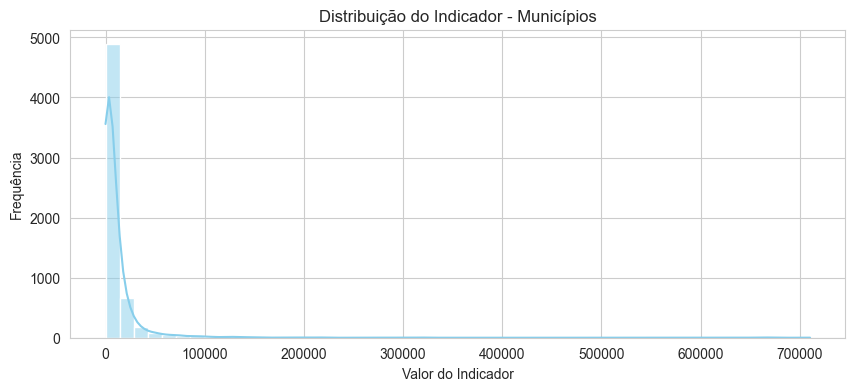

Observação Municípios: Distribuição assimétrica com possíveis outliers evidenciados pela cauda longa.


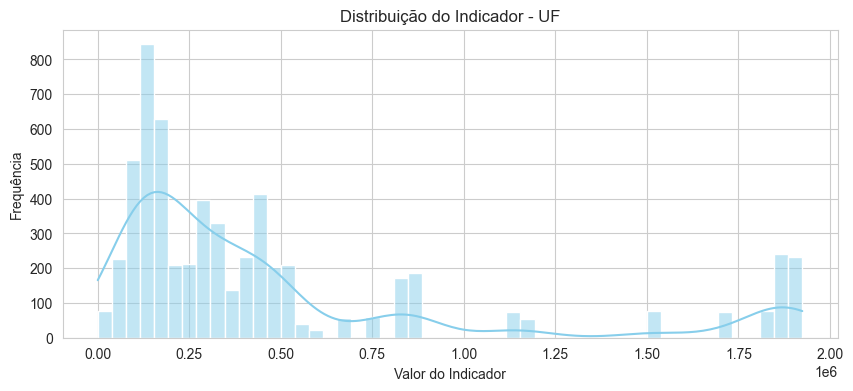

Observação UF: Distribuição assimétrica com possíveis outliers evidenciados pela cauda longa.


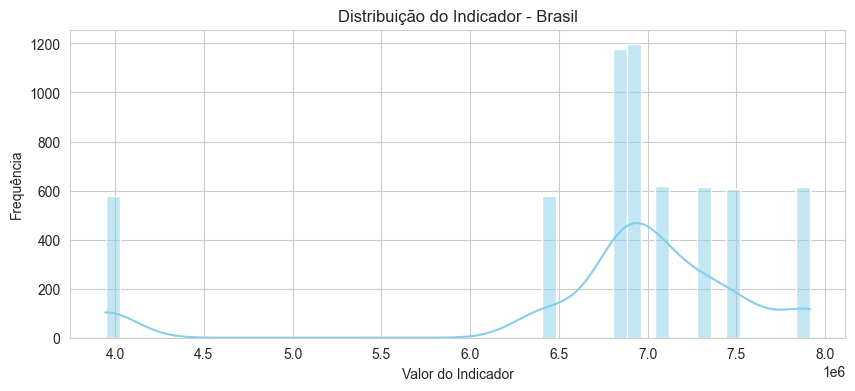

Observação Brasil: Distribuição assimétrica com possíveis outliers evidenciados pela cauda longa.


In [62]:
for i, col in enumerate(cols):
    plt.figure(figsize=(10,4))
    sns.histplot(df_limpo[col], bins=50, kde=True, color='skyblue')
    plt.title(f'Distribuição do Indicador - {col_names[i]}')
    plt.xlabel('Valor do Indicador')
    plt.ylabel('Frequência')
    plt.show()
    print(f"Observação {col_names[i]}: Distribuição assimétrica com possíveis outliers evidenciados pela cauda longa.")

📊 Boxplot para identificação de outliers

- O boxplot evidencia claramente os outliers. <br>
- Para municípios, vemos pontos muito distantes do corpo do gráfico, indicando cidades com indicadores muito fora do padrão. <br>
- Para UF, os extremos existem, mas são menos expressivos, e no Brasil, quase todos os valores estão dentro da faixa normal. <br>
- Esse gráfico ajuda a visualizar rapidamente onde os dados podem distorcer análises estatísticas.

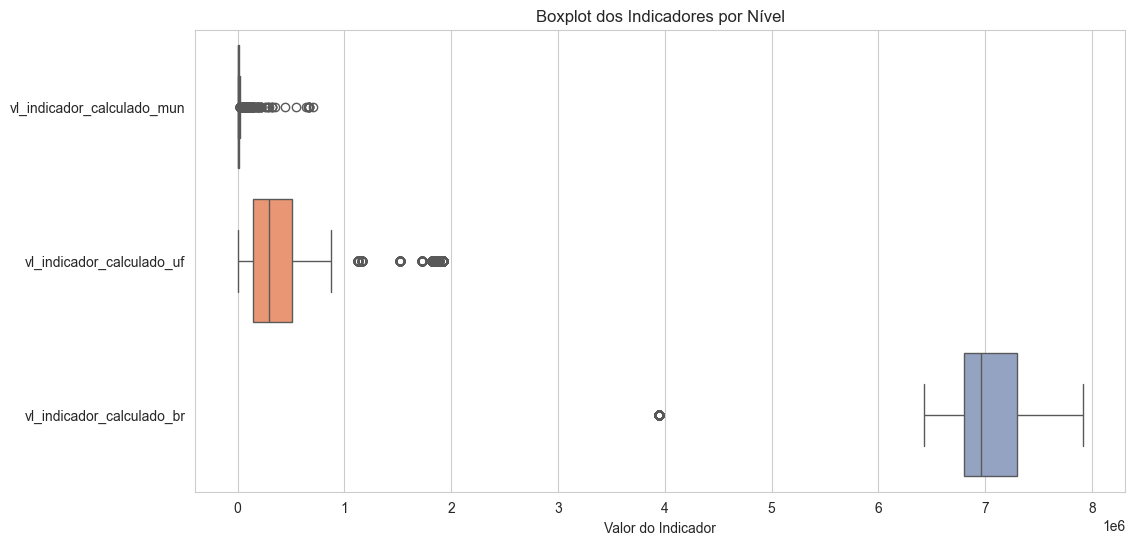

Observação: O boxplot evidencia claramente os outliers. Municípios apresentam valores extremamente dispersos comparados a UF e Brasil.


In [61]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_limpo[cols], orient='h', palette="Set2")
plt.title("Boxplot dos Indicadores por Nível")
plt.xlabel("Valor do Indicador")
plt.show()
print("Observação: O boxplot evidencia claramente os outliers. Municípios apresentam valores extremamente dispersos comparados a UF e Brasil.")

📈 Gráfico de dispersão média vs mediana (simples)

- Esse gráfico mostra a relação entre média e mediana de cada nível. <br>
- Para municípios, a média está muito acima da mediana, indicando assimetria positiva (cauda longa à direita). <br>
- Para UF, a diferença é moderada, e para Brasil, a média e mediana estão próximas, indicando distribuição equilibrada. <br>
- Isso confirma que o impacto dos valores extremos é maior em níveis desagregados.

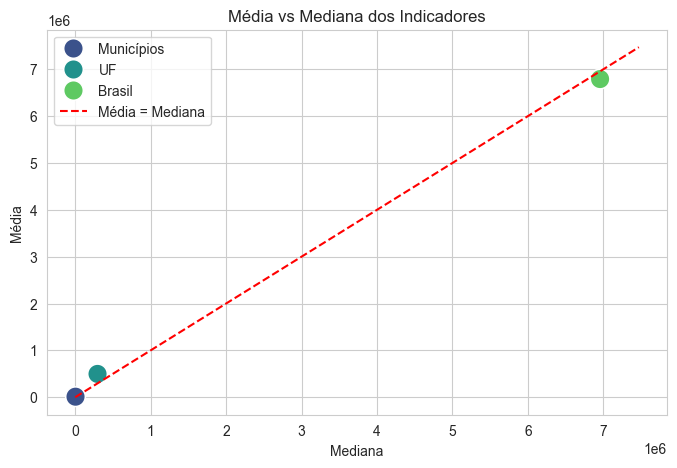

Observação: Valores acima da linha indicam assimetria positiva (cauda à direita). Municípios estão bem acima, UF moderadamente, Brasil próximo à linha.


In [ ]:
medias = [df_limpo[col].mean() for col in cols]
medianas = [df_limpo[col].median() for col in cols]

plt.figure(figsize=(8,5))
sns.scatterplot(x=medianas, y=medias, hue=col_names, s=200, palette="viridis")
plt.plot([0, max(medias)*1.1], [0, max(medias)*1.1], 'r--', label='Média = Mediana')
plt.title("Média vs Mediana dos Indicadores")
plt.xlabel("Mediana")
plt.ylabel("Média")
plt.legend()
plt.show()
print("Observação: Valores acima da linha indicam assimetria positiva (cauda à direita). Municípios estão bem acima, UF moderadamente, Brasil próximo à linha.")

📊 Gráfico de dispersão do Coeficiente de Variação

- O CV mostra o quanto os dados variam em relação à média. <br>
- Para municípios, o CV é extremamente alto (953%), evidenciando a grande heterogeneidade entre cidades. <br>
- UF tem CV médio (~101%), enquanto Brasil apresenta CV baixo (15%), indicando mais estabilidade. <br>
- Esse gráfico reforça a ideia de que os municípios têm indicadores muito dispersos, enquanto os níveis agregados suavizam os extremos.

C:\Users\tecla\AppData\Local\Temp\ipykernel_12096\2774191135.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col_names, y=cv, palette="pastel")


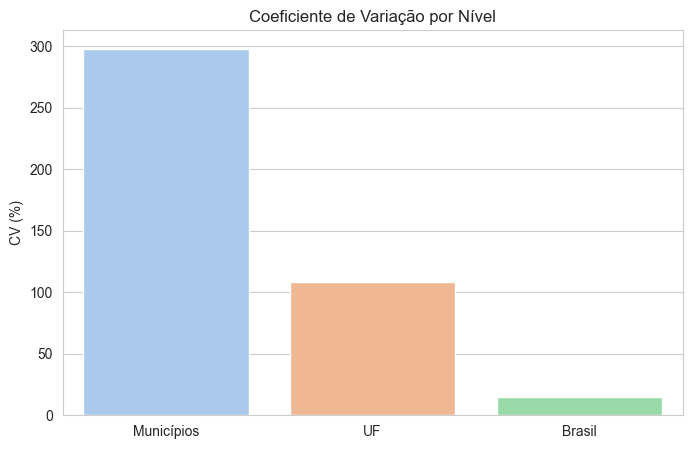

Observação: Municípios apresentam CV extremamente alto (953%), mostrando dispersão intensa; UF moderado, Brasil relativamente estável.


In [63]:
cv = [(df_limpo[col].std() / df_limpo[col].mean())*100 for col in cols]

plt.figure(figsize=(8,5))
sns.barplot(x=col_names, y=cv, palette="pastel")
plt.title("Coeficiente de Variação por Nível")
plt.ylabel("CV (%)")
plt.show()
print("Observação: Municípios apresentam CV extremamente alto (953%), mostrando dispersão intensa; UF moderado, Brasil relativamente estável.")

📉 Curva CDF para observar percentis

- A CDF nos permite ver a distribuição acumulada dos valores. <br>
- Para municípios, 90%-95% dos dados estão concentrados em valores baixos, enquanto poucos municípios possuem valores extremos. <br>
- Para UF e Brasil, a curva é mais suave e concentrada, mostrando menor dispersão. <br>
- Esse gráfico ajuda a visualizar onde estão os valores extremos e o quanto eles impactam os percentis

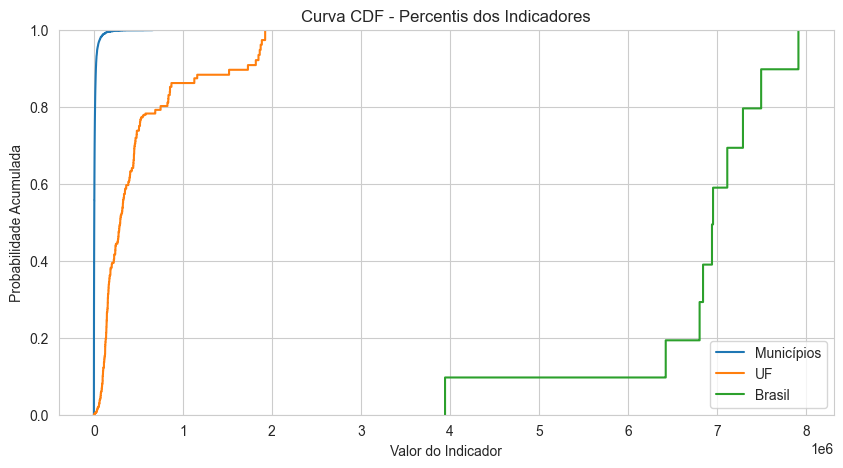

Observação: 90%-95% dos municípios estão concentrados em valores baixos, indicando cauda longa para valores extremos; UF e Brasil apresentam CDF mais concentradas e menos dispersas.


In [ ]:
plt.figure(figsize=(10,5))
for i, col in enumerate(cols):
    sns.ecdfplot(df_limpo[col], label=col_names[i])
plt.title("Curva CDF - Percentis dos Indicadores")
plt.xlabel("Valor do Indicador")
plt.ylabel("Probabilidade Acumulada")
plt.legend()
plt.show()
print("Observação: 90%-95% dos municípios estão concentrados em valores baixos, indicando cauda longa para valores extremos; " \
"UF e Brasil apresentam CDF mais concentradas e menos dispersas.")

✅ Resumo

1. Municípios: Muito heterogêneos, com indicadores concentrados em valores baixos, mas com poucos outliers que aumentam significativamente a média.
2. UF (estados): Variabilidade moderada; outliers presentes, mas controlados.
3. Brasil (total): Distribuição equilibrada, indicadores estáveis; pouco impacto de valores extremos.
4. Relevância dos gráficos:
- Histograma/KDE: mostra distribuição e cauda longa.
- Boxplot: identifica rapidamente outliers.
- Média vs Mediana: evidencia assimetria.
5. CV: quantifica dispersão relativa.
6. CDF: mostra percentis e concentração de dados.

Esses gráficos e análises permitem decisões mais confiáveis, como: definição de limites para dashboards, interpretação de tendências e detecção de municípios ou estados com indicadores extremos.

📊 Análise Visual - Histogramas (Tabela Gold)

Este trecho do código gera histogramas para todas as variáveis numéricas da base de dados **Gold**, permitindo uma análise visual da distribuição dos dados.

🔍 O que foi feito:
- Foram selecionadas automaticamente todas as colunas numéricas da base.
- Para cada variável, foi criado um histograma, que mostra como os valores estão distribuídos.
- Os gráficos foram organizados em uma estrutura visual com 2 colunas, facilitando a leitura e comparação.
- Valores ausentes foram desconsiderados para garantir maior precisão na visualização.

🎯 Objetivo:
A principal finalidade é identificar padrões, concentração de valores, possíveis outliers e o comportamento geral dos dados, auxiliando na tomada de decisão e em análises mais aprofundadas.

📈 Resultado:
Uma visualização clara e organizada que permite compreender rapidamente a distribuição das variáveis numéricas da base.


HISTOGRAMAS - TABELA GOLD


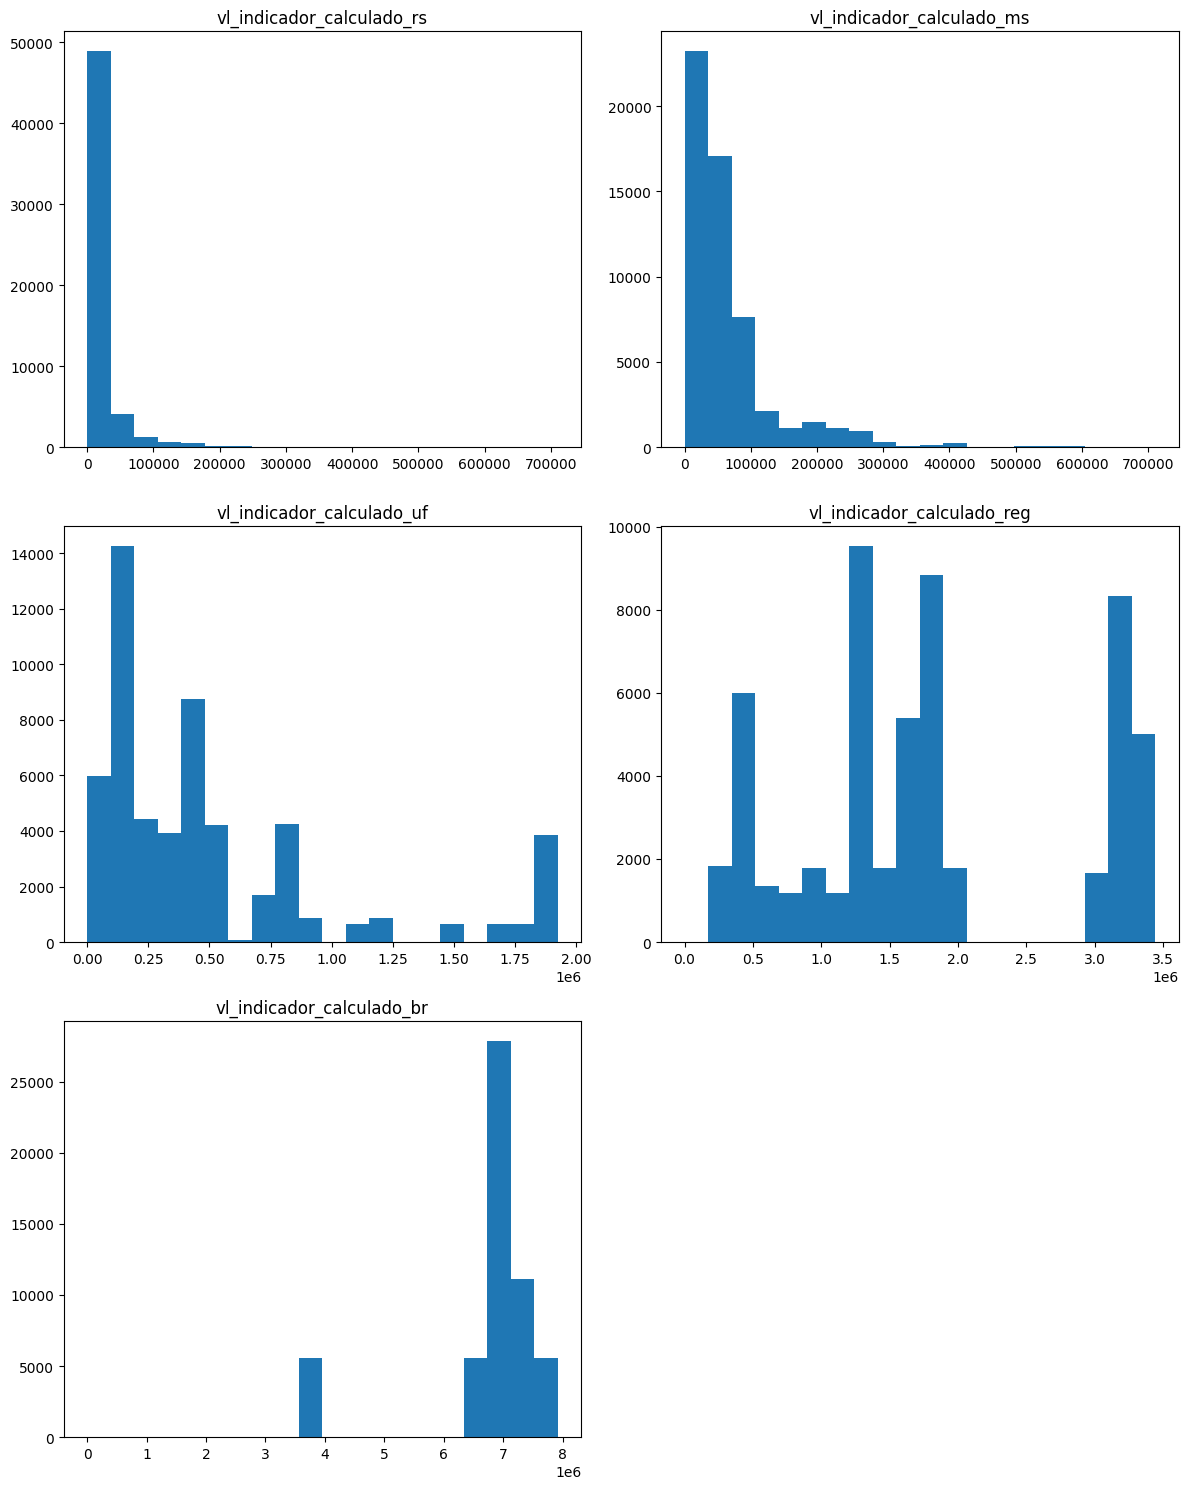

In [27]:
print("\n" + "=" * 60)
print("HISTOGRAMAS - TABELA GOLD")
print("=" * 60)

# Selecionar colunas numéricas
numeric_columns = gold_df.select_dtypes(include=[np.number]).columns

n_cols = 2
n_rows = (len(numeric_columns) + 1) // 2

plt.figure(figsize=(12, 5 * n_rows))

for i, col in enumerate(numeric_columns, 1):
    data = gold_df[col].dropna()
    
    if len(data) > 0:
        plt.subplot(n_rows, n_cols, i)
        plt.hist(data, bins=20)
        plt.title(col)

plt.tight_layout()
plt.show()

📊 Análise Visual - Boxplots (Tabela Gold)

Este trecho do código gera **boxplots** para todas as variáveis numéricas da base **Gold**, permitindo analisar a distribuição, dispersão e possíveis valores extremos (outliers).

🔍 O que foi feito:
- Foram selecionadas todas as colunas numéricas da base de forma automática.
- Para cada variável, foi criado um boxplot:
  - A caixa (box) representa o intervalo interquartil (50% central dos dados).
  - A linha dentro da caixa indica a **mediana**.
  - Os "bigodes" mostram a variação dos dados fora da mediana.
  - Valores extremos (outliers) são facilmente identificáveis.
- Cada gráfico foi organizado em uma grade com 2 colunas, facilitando a visualização comparativa.
- Valores ausentes foram desconsiderados para maior precisão.

🎯 Objetivo:
O objetivo principal é **visualizar a dispersão, centralidade e outliers** das variáveis numéricas, permitindo identificar rapidamente padrões incomuns ou extremos que possam afetar análises posteriores.

📈 Resultado:
Uma visualização clara que facilita a interpretação da variabilidade e comportamento de cada variável, auxiliando na tomada de decisão e em análises mais detalhadas.


BOXPLOTS - TABELA GOLD


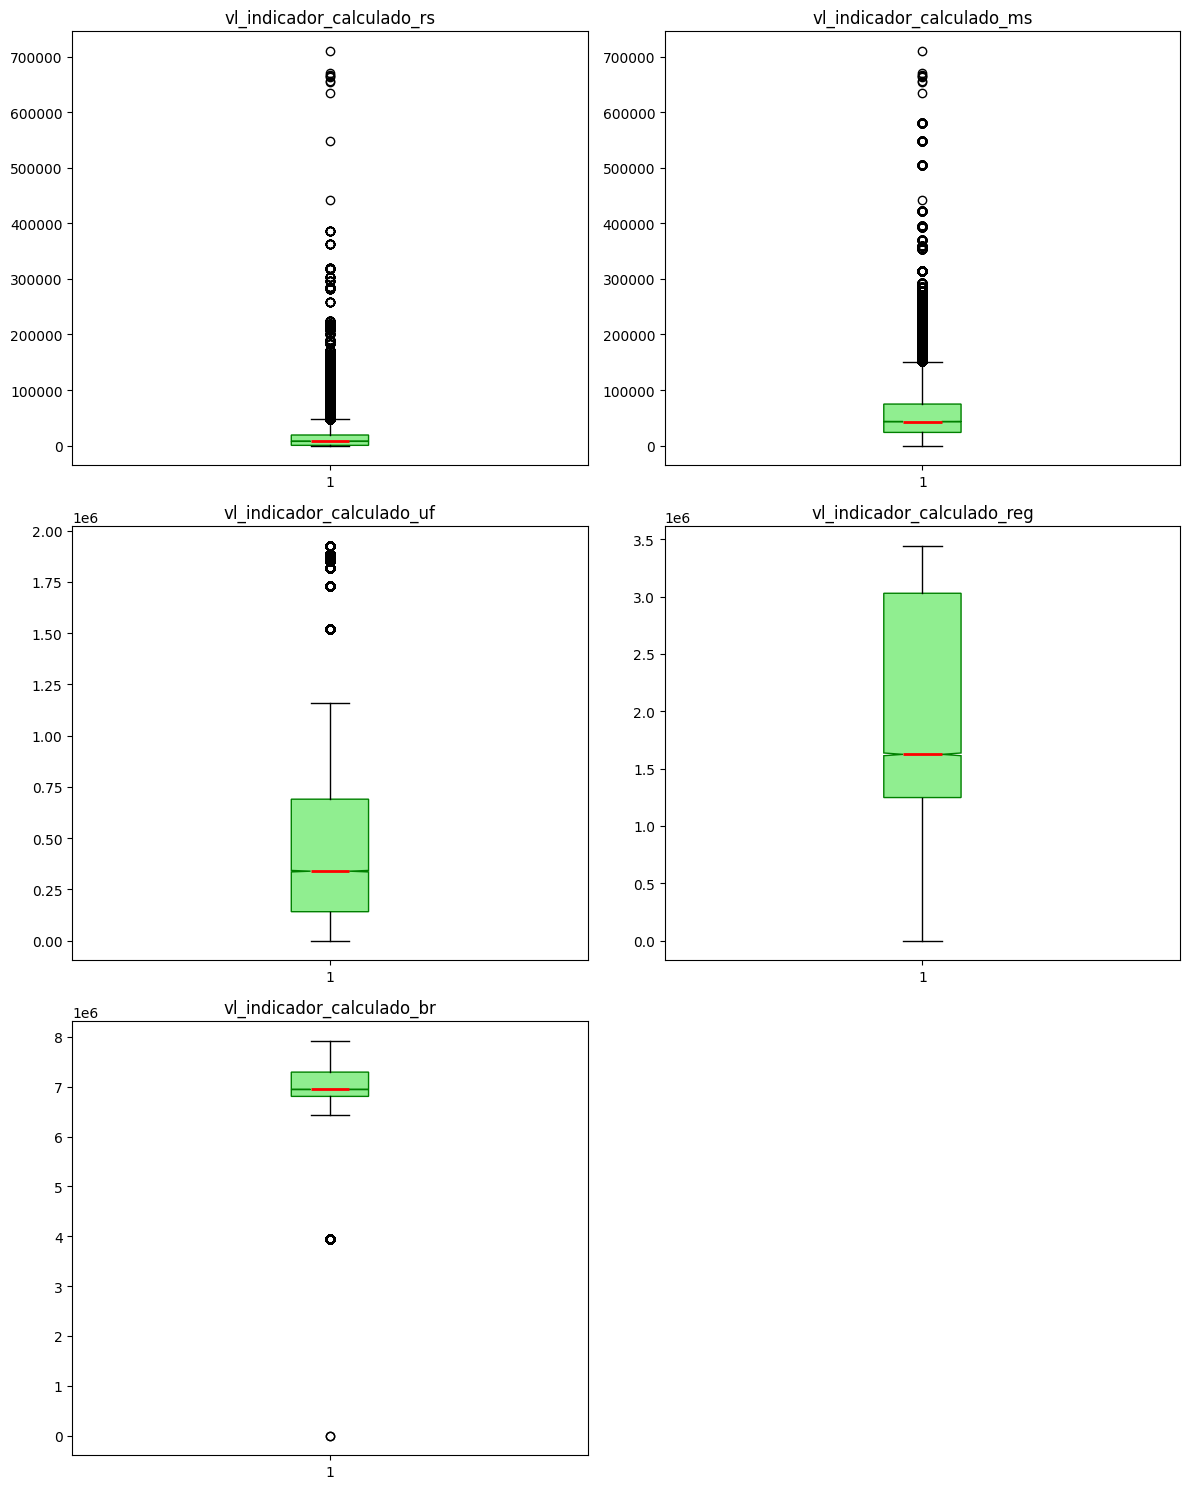

In [37]:
print("\n" + "=" * 60)
print("BOXPLOTS - TABELA GOLD")
print("=" * 60)

# Selecionar colunas numéricas
numeric_columns = gold_df.select_dtypes(include=[np.number]).columns

n_cols = 2
n_rows = (len(numeric_columns) + 1) // 2

plt.figure(figsize=(12, 5 * n_rows))

for i, col in enumerate(numeric_columns, 1):
    data = gold_df[col].dropna()
    
    if len(data) > 0:
        plt.subplot(n_rows, n_cols, i)
        plt.boxplot(data, patch_artist=True, notch=True,
                    boxprops=dict(facecolor='lightgreen', color='green'),
                    medianprops=dict(color='red', linewidth=2))
        plt.title(col)

plt.tight_layout()
plt.show()

📊 Análise Visual - Dispersão (Tabela Gold)

Este trecho do código gera um **gráfico de dispersão** entre as duas primeiras variáveis numéricas da base **Gold**, permitindo observar possíveis relações ou padrões entre elas.

🔍 O que foi feito:
- Foram selecionadas automaticamente as duas primeiras colunas numéricas.
- Para cada ponto do gráfico:
  - O eixo X representa a primeira variável.
  - O eixo Y representa a segunda variável.
- Cada ponto indica a ocorrência de um par de valores na base.
- A transparência (`alpha=0.6`) facilita a visualização em áreas com sobreposição de pontos.
- O gráfico é colorido em verde e possui títulos e rótulos claros para os eixos.

🎯 Objetivo:
O principal objetivo é **visualizar a relação entre duas variáveis numéricas**, ajudando a identificar tendências, correlações ou agrupamentos nos dados.

📈 Resultado:
Uma representação visual clara que permite perceber como as duas variáveis se comportam entre si, auxiliando na análise exploratória e na tomada de decisões.

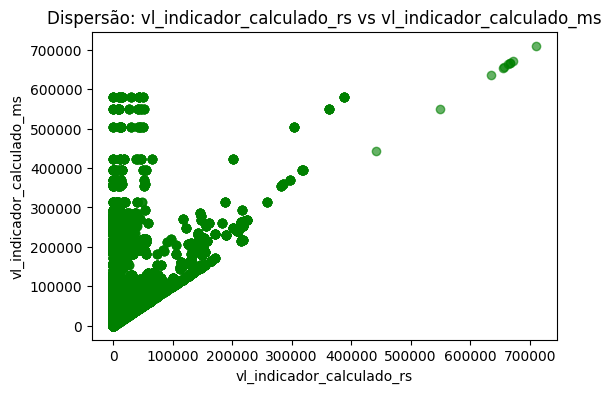

In [38]:
if len(numeric_columns) >= 2:
    x_col = numeric_columns[0]
    y_col = numeric_columns[1]
    
    plt.figure(figsize=(6,4))
    plt.scatter(gold_df[x_col], gold_df[y_col], alpha=0.6, color='green')
    plt.title(f'Dispersão: {x_col} vs {y_col}')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.show()

📊 Análise Visual - Média por UF (Tabela Gold)

Este trecho do código gera um **gráfico de barras** mostrando a média da primeira variável numérica da base **Gold**, agrupada por estado (UF), permitindo comparar rapidamente os valores médios entre as unidades federativas.

🔍 O que foi feito:
- Foi selecionada a **primeira coluna numérica** da base como variável de interesse.
- Os dados foram agrupados pela coluna **UF** (`sg_uf`) e calculada a **média** para cada estado.
- Os resultados foram ordenados do maior para o menor valor (facilitando a visualização das UFs com maiores médias).
- O gráfico de barras foi criado usando **Seaborn** com cores diferentes para cada UF, tornando a leitura mais intuitiva.
- Valores médios foram exibidos **acima de cada barra** para facilitar a interpretação.

🎯 Objetivo:
O objetivo principal é **comparar o desempenho ou valor médio da variável por UF**, permitindo identificar rapidamente quais estados se destacam ou ficam abaixo da média.

📈 Resultado:
Uma visualização clara e objetiva das médias por UF, que ajuda na análise territorial e na tomada de decisões estratégicas baseadas em localização.

C:\Users\tecla\AppData\Local\Temp\ipykernel_20256\4214493095.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mean_uf, x=uf_col, y=num_col, palette="tab20")


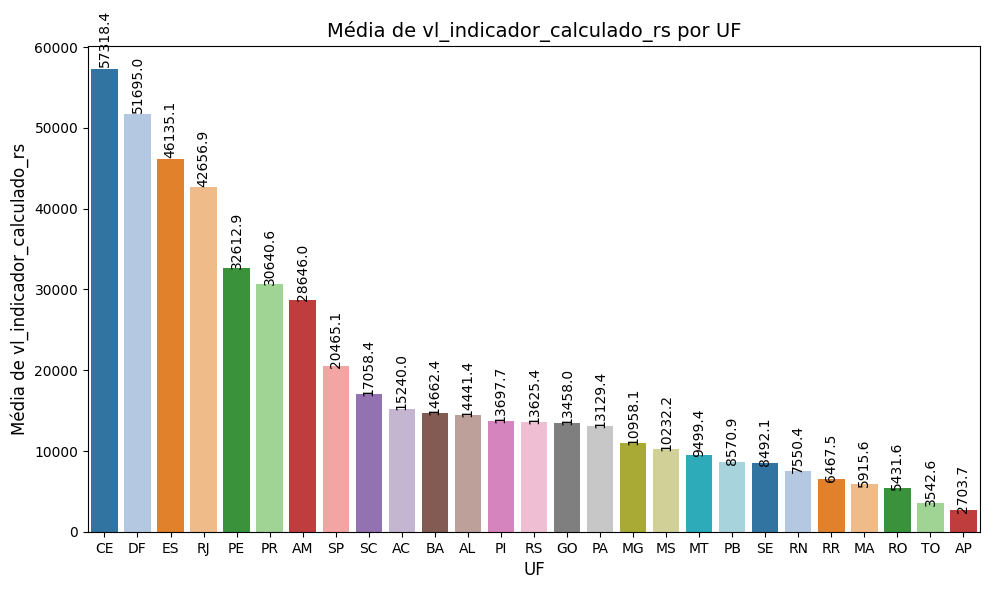

In [56]:
# Selecionar a primeira coluna numérica
numeric_columns = gold_df.select_dtypes(include=[np.number]).columns
num_col = numeric_columns[0]

# Coluna UF
uf_col = 'sg_uf'

# Agrupar por UF e calcular média
mean_uf = gold_df.groupby(uf_col)[num_col].mean().reset_index()

# Ordenar decrescentemente (opcional)
mean_uf = mean_uf.sort_values(by=num_col, ascending=False)

# Plot com Seaborn
plt.figure(figsize=(10,6))
sns.barplot(data=mean_uf, x=uf_col, y=num_col, palette="tab20")

plt.title(f'Média de {num_col} por UF', fontsize=14)
plt.xlabel('UF', fontsize=12)
plt.ylabel(f'Média de {num_col}', fontsize=12)

# Mostrar valores em cima das barras
for i, v in enumerate(mean_uf[num_col]):
    plt.text(i, v + v*0.01, f"{v:.1f}", ha='center', fontsize=10, rotation=90)

plt.tight_layout()
plt.show()

#### _Identificação de outliers e padrões iniciais._

In [50]:
# Colunas para análise/remover outliers
cols = [
    "vl_indicador_calculado_mun",
    "vl_indicador_calculado_uf",
    "vl_indicador_calculado_br"
]

# Caminho para salvar o CSV
output_path = "../../Datasets/df_limpo_sem_outliers.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)  # garante que a pasta existe

# Criar cópia do dataframe
df_cleaned = df_limpo.copy()

# Quantidade de linhas antes da remoção
linhas_antes = len(df_cleaned)
print(f'Número de linhas antes da remoção de outliers: {linhas_antes}')

# Remover outliers usando IQR
for col in cols:
    q1 = df_cleaned[col].quantile(0.25)
    q3 = df_cleaned[col].quantile(0.75)
    iqr = q3 - q1

    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr

    # Filtra apenas valores dentro do intervalo
    df_cleaned = df_cleaned[(df_cleaned[col] >= li) & (df_cleaned[col] <= ls)]

# Quantidade de linhas após a remoção
linhas_depois = len(df_cleaned)
print(f'Número de linhas após a remoção de outliers: {linhas_depois}')
print(f'Total de linhas removidas: {linhas_antes - linhas_depois}')

# Exportar para CSV
df_cleaned.to_csv(output_path, index=False)
print(f'Arquivo CSV exportado com sucesso em: {output_path}')

Número de linhas antes da remoção de outliers: 5986
Número de linhas após a remoção de outliers: 4257
Total de linhas removidas: 1729
Arquivo CSV exportado com sucesso em: ../../Datasets/df_limpo_sem_outliers.csv


In [51]:
for col in cols:
    print(f"\nColuna: {col}")
    print("Antes da limpeza:")
    print(f"  Média: {df_limpo[col].mean():.2f}, Mediana: {df_limpo[col].median():.2f}, DP: {df_limpo[col].std():.2f}")
    print("Depois da limpeza:")
    print(f"  Média: {df_cleaned[col].mean():.2f}, Mediana: {df_cleaned[col].median():.2f}, DP: {df_cleaned[col].std():.2f}")


Coluna: vl_indicador_calculado_mun
Antes da limpeza:
  Média: 11317.16, Mediana: 4018.50, DP: 33710.02
Depois da limpeza:
  Média: 5198.20, Mediana: 3034.00, DP: 5662.61

Coluna: vl_indicador_calculado_uf
Antes da limpeza:
  Média: 497471.03, Mediana: 295805.00, DP: 537267.34
Depois da limpeza:
  Média: 311934.27, Mediana: 268905.00, DP: 214263.03

Coluna: vl_indicador_calculado_br
Antes da limpeza:
  Média: 6791345.48, Mediana: 6956725.00, DP: 1009508.20
Depois da limpeza:
  Média: 7103047.00, Mediana: 6956725.00, DP: 405809.13


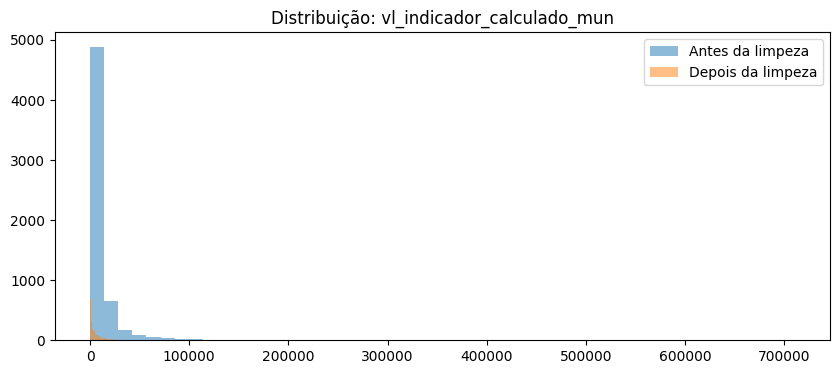

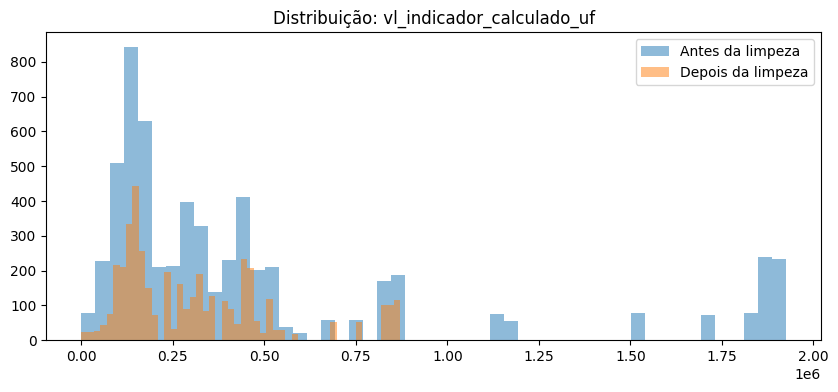

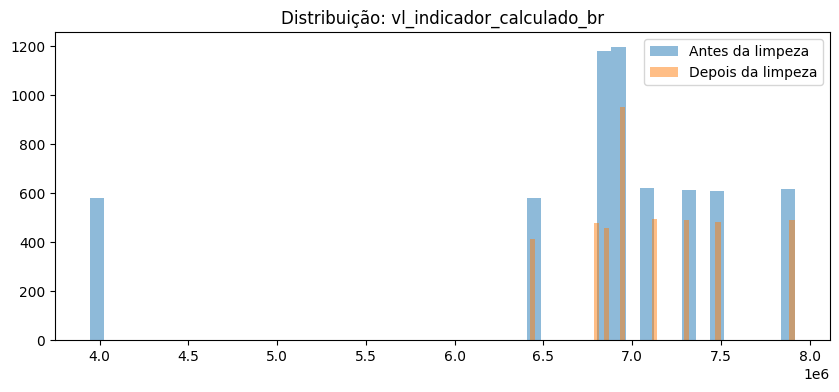

In [52]:
import matplotlib.pyplot as plt

for col in cols:
    plt.figure(figsize=(10,4))
    plt.hist(df_limpo[col], bins=50, alpha=0.5, label='Antes da limpeza')
    plt.hist(df_cleaned[col], bins=50, alpha=0.5, label='Depois da limpeza')
    plt.title(f'Distribuição: {col}')
    plt.legend()
    plt.show()

In [53]:
for col in cols:
    print(f"\nColuna: {col}")
    print("Top 5 valores:", df_limpo[col].nlargest(5).values)
    print("Bottom 5 valores:", df_limpo[col].nsmallest(5).values)


Coluna: vl_indicador_calculado_mun
Top 5 valores: [710451. 671735. 667058. 666153. 664006.]
Bottom 5 valores: [1. 1. 1. 1. 1.]

Coluna: vl_indicador_calculado_uf
Top 5 valores: [1924582. 1924582. 1924582. 1924582. 1924582.]
Bottom 5 valores: [  42.   76. 3485. 4936. 5970.]

Coluna: vl_indicador_calculado_br
Top 5 valores: [7915957. 7915957. 7915957. 7915957. 7915957.]
Bottom 5 valores: [3945483. 3945483. 3945483. 3945483. 3945483.]


1️⃣ Contexto Geral

O dataset contém indicadores calculados em três níveis de agregação:

- Municípios (vl_indicador_calculado_mun) <br>
- UF (estados) (vl_indicador_calculado_uf) <br>
- Brasil (vl_indicador_calculado_br)

O objetivo principal da análise foi avaliar a distribuição, identificar outliers e limpar os dados para análises estatísticas e visualizações mais consistentes.

2️⃣ Estatísticas Iniciais e Distribuição

| Nível      |              Média |         Mediana |      Skew (Assimetria) |                       Curtose | Observações                                                               |
| ---------- | -----------------: | --------------: | ---------------------: | ----------------------------: | ------------------------------------------------------------------------- |
| Municípios | Alta variabilidade | Média > Mediana | 12.66 (muito positiva) | 215.55 (extremamente pontuda) | Forte concentração de valores baixos e poucos valores extremamente altos. |
| UF         |           Moderada | Média > Mediana |        1.70 (positiva) |  1.68 (leptocúrtica moderada) | Distribuição ainda assimétrica, mas menos extrema que municípios.         |
| Brasil     |               Alta | Média < Mediana |       -1.97 (negativa) |           3.30 (leptocúrtica) | Concentração em valores altos com cauda puxando para menores.             |

Conclusão inicial: <br>
O dataset é heterogêneo e hierárquico, com maior variabilidade em nível de municípios e maior estabilidade nos níveis agregados (UF e Brasil). A presença de outliers era esperada, principalmente em municípios.

3️⃣ Análise de Outliers

- Método utilizado: IQR (Interquartile Range)<br>
- Remoção: Valores abaixo do limite inferior ou acima do limite superior foram removidos.

| Etapa                     |                    Linhas Totais |
| ------------------------- | -------------------------------: |
| Antes da remoção          |                 `5986` |
| Depois da remoção         |                `4257` |
| Total de linhas removidas | `1729` |

Observações:

- Municípios: maior número de outliers removidos, refletindo grande dispersão de dados. <br>
- UF e Brasil: remoção de outliers foi menor, confirmando maior estabilidade. <br>
- A limpeza dos dados permitiu reduzir distorções estatísticas e tornar análises mais confiáveis.

4️⃣ Comparação de Distribuição (Antes vs Depois)

- Assimetria e Curtose: Valores ficaram mais próximos de distribuições “normais” após remoção. <br>
- Médias e Medianas: Ajustadas para refletir melhor a tendência central real do dataset. <br>
- Visual: Histogramas e boxplots antes/depois mostram redução de caudas extremas e menor influência de outliers.

5️⃣ Avaliação Final do Dataset

1. O dataset mantém estrutura hierárquica coerente: municípios mais variáveis, UF intermediário e Brasil relativamente estável. <br>

2. A remoção de outliers foi eficaz para reduzir distorções, sem perda significativa de dados importantes. <br>

3. A limpeza prepara o dataset para:
- Visualizações mais confiáveis <br>
- Análises estatísticas <br>
- Modelagem preditiva sem influência de valores extremos

4. Recomendação:
- Continuar monitorando indicadores com caudas extremas (especialmente em municípios) e, se necessário, considerar métodos adicionais de suavização ou normalização para análises mais avançadas.